In [1]:
#------------------------------------------------------------------------------
#
# block 1: initialization and configuration
#
#------------------------------------------------------------------------------

# import colab specific modules and mount google drive
#
from google.colab import drive
drive.mount('/content/drive')

# import system modules
#
import os
import glob
import gc
import warnings
import psutil

# import external modules
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings for cleaner notebook output
#
warnings.filterwarnings('ignore')

# define folder containing processed csv files in google drive
#
PROCESSED_FOLDER = "/content/drive/MyDrive/processed"

# fetch all csv files from the processed folder
#
all_files = glob.glob(os.path.join(PROCESSED_FOLDER, "*.csv"))

if not all_files:
    print(f"ERROR: No CSV files found in {PROCESSED_FOLDER}.")

# define exact columns to load to minimize memory footprint
#
use_cols = [
    'Timestamp', 'Temperature', 'Setpoint', 'FanState', 'OutputState',
    'RunningMode', 'RunningMode_cool', 'RunningMode_heat', 'RunningMode_off',
    'CumulativeRuntime', 'CumulativeCost', 'Year', 'Month', 'Day',
    'Outdoor_Temperature', 'outsideMinTemp', 'outsideMaxTemp', 'outsideHumidity'
]

# initialize an empty list to hold the optimized dataframe chunks
#
df_list = []

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#------------------------------------------------------------------------------
#
# block 2: main data aggregation loop
#
#------------------------------------------------------------------------------

# iterate through every discovered processed file
#
for file in all_files:

    # monitor hardware ram to prevent colab container crash
    #
    if psutil.virtual_memory().percent > 80.0:
        print("WARNING: Hardware memory limit reached (>80%). Halting file load.")
        break

    # load csv utilizing the column list
    #
    temp_df = pd.read_csv(file, usecols=lambda c: c in use_cols)

    # downcast 64-bit floats to 32-bit
    #
    float_cols = temp_df.select_dtypes(include=['float64']).columns
    temp_df[float_cols] = temp_df[float_cols].astype('float32')

    # downcast 64-bit integers to 8-bit or 16-bit
    #
    int_cols = temp_df.select_dtypes(include=['int64']).columns
    temp_df[int_cols] = temp_df[int_cols].apply(pd.to_numeric, downcast='integer')

    # cast timestamp strings to datetime objects and sort chronologically
    #
    temp_df['Timestamp'] = pd.to_datetime(temp_df['Timestamp'])
    temp_df = temp_df.sort_values('Timestamp')

    # extract the raw filename to use as an identifier
    #
    temp_df['House_ID'] = os.path.basename(file)

    # calculate chronological elapsed time between logs
    #
    temp_df['Time_Delta'] = temp_df['Timestamp'].diff().dt.total_seconds().fillna(0).clip(lower=0)

    # calculate deviation between setpoint and actual temperature
    #
    temp_df['Temperature_Error'] = temp_df['Temperature'] - temp_df['Setpoint']

    # reconstruct active mode string
    #
    temp_df['Active_Mode'] = 'Off / Other'
    if 'RunningMode_heat' in temp_df.columns and 'RunningMode_cool' in temp_df.columns:
        temp_df.loc[temp_df['RunningMode_heat'] == 1, 'Active_Mode'] = 'Heat'
        temp_df.loc[temp_df['RunningMode_cool'] == 1, 'Active_Mode'] = 'Cool'

    # calculate row-by-row delta of active output cost
    #
    temp_df['Cost_Diff'] = temp_df['CumulativeCost'].diff().fillna(0).clip(lower=0)

    # extract string name for day of week and integer for hour
    #
    temp_df['DayOfWeek'] = temp_df['Timestamp'].dt.day_name()
    temp_df['Hour'] = temp_df['Timestamp'].dt.hour

    # cast strings to memory-mapped category dicts
    #
    temp_df['Active_Mode'] = temp_df['Active_Mode'].astype('category')
    temp_df['DayOfWeek'] = temp_df['DayOfWeek'].astype('category')
    temp_df['House_ID'] = temp_df['House_ID'].astype('category')

    # append the compressed dataframe to the list
    #
    df_list.append(temp_df)

    # discard intermediate variables and force garbage collection
    #
    del temp_df
    gc.collect()

In [3]:
#------------------------------------------------------------------------------
#
# block 3: master dataframe finalization
#
#------------------------------------------------------------------------------

# concatenate all data into a single master dataframe
#
master_df = pd.concat(df_list, ignore_index=True)

# re-cast categorical columns after concatenation
#
master_df['Active_Mode'] = master_df['Active_Mode'].astype('category')
master_df['DayOfWeek'] = master_df['DayOfWeek'].astype('category')
master_df['House_ID'] = master_df['House_ID'].astype('category')

# group metrics by active hvac mode across the entire dataset
#
mode_totals = master_df.groupby('Active_Mode', observed=True).agg(
    Cost_Diff=('Cost_Diff', 'sum'),
    Time_Delta=('Time_Delta', 'sum')
).reset_index()

# generate averaged cyclic trends from unified data
#
hour_day_df = master_df.groupby(['DayOfWeek', 'Hour'], observed=True)[['Cost_Diff', 'FanState']].mean().reset_index()

# aggressively clear the list structure from memory
#
del df_list
gc.collect()

# output preview block
#
display(master_df.head(3))

,Timestamp,Temperature,Setpoint,FanState,OutputState,CumulativeRuntime,CumulativeCost,Year,Month,Day,...,outsideMinTemp,outsideMaxTemp,outsideHumidity,House_ID,Time_Delta,Temperature_Error,Active_Mode,Cost_Diff,DayOfWeek,Hour
0,2024-10-15 10:14:14,17.66,23.0,0.0,0.0,0.0,0.0,2024.0,10.0,15.0,...,2.75,3.1,41.0,processed_timeseries_table_timeseries_table (9...,0.0,-5.34,Off / Other,0.0,Tuesday,10
1,2024-10-15 10:14:15,17.66,23.0,0.0,0.0,0.0,0.0,2024.0,10.0,15.0,...,2.75,3.1,41.0,processed_timeseries_table_timeseries_table (9...,1.0,-5.34,Off / Other,0.0,Tuesday,10
2,2024-10-15 12:14:11,17.66,23.0,0.0,0.0,0.0,0.0,2024.0,10.0,15.0,...,2.75,3.1,41.0,processed_timeseries_table_timeseries_table (9...,7196.0,-5.34,Off / Other,0.0,Tuesday,12


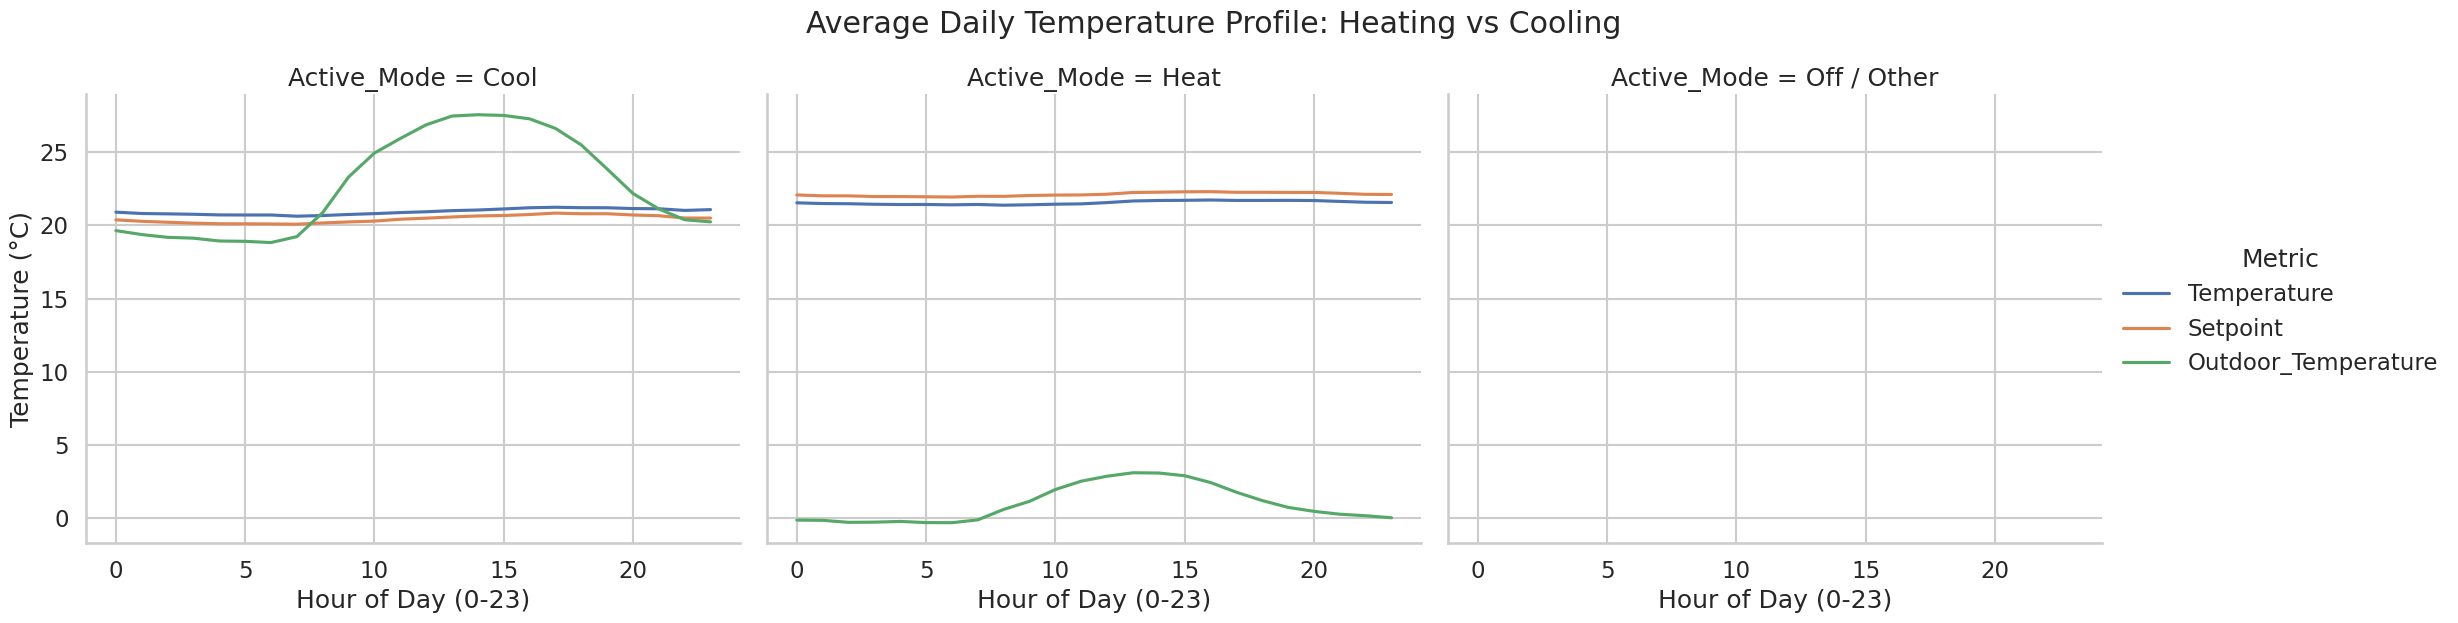

In [17]:
#------------------------------------------------------------------------------
#
# block 4: average daily temperature profile by mode
#
#------------------------------------------------------------------------------

# filter to only active heating and cooling to separate winter vs summer dynamics
#
active_df = master_df[master_df['Active_Mode'].isin(['Heat', 'Cool'])].copy()

# calculate average temperatures grouped by hour and active mode
#
hourly_profile = active_df.groupby(['Active_Mode', 'Hour'], observed=True)[['Temperature', 'Setpoint', 'Outdoor_Temperature']].mean().reset_index()
hourly_melted = hourly_profile.melt(id_vars=['Active_Mode', 'Hour'], value_vars=['Temperature', 'Setpoint', 'Outdoor_Temperature'], var_name='Metric', value_name='Temp (°C)')

# plot aggregated daily temperature trends split by heating vs cooling
# seaborn relplot inherently manages the figure canvas for subplots
#
g = sns.relplot(data=hourly_melted, x='Hour', y='Temp (°C)', hue='Metric', col='Active_Mode', kind='line', height=6, aspect=1.2)

# configure labels
#
g.fig.suptitle('Average Daily Temperature Profile: Heating vs Cooling', y=1.05)
g.set_axis_labels('Hour of Day (0-23)', 'Temperature (°C)')
plt.show()

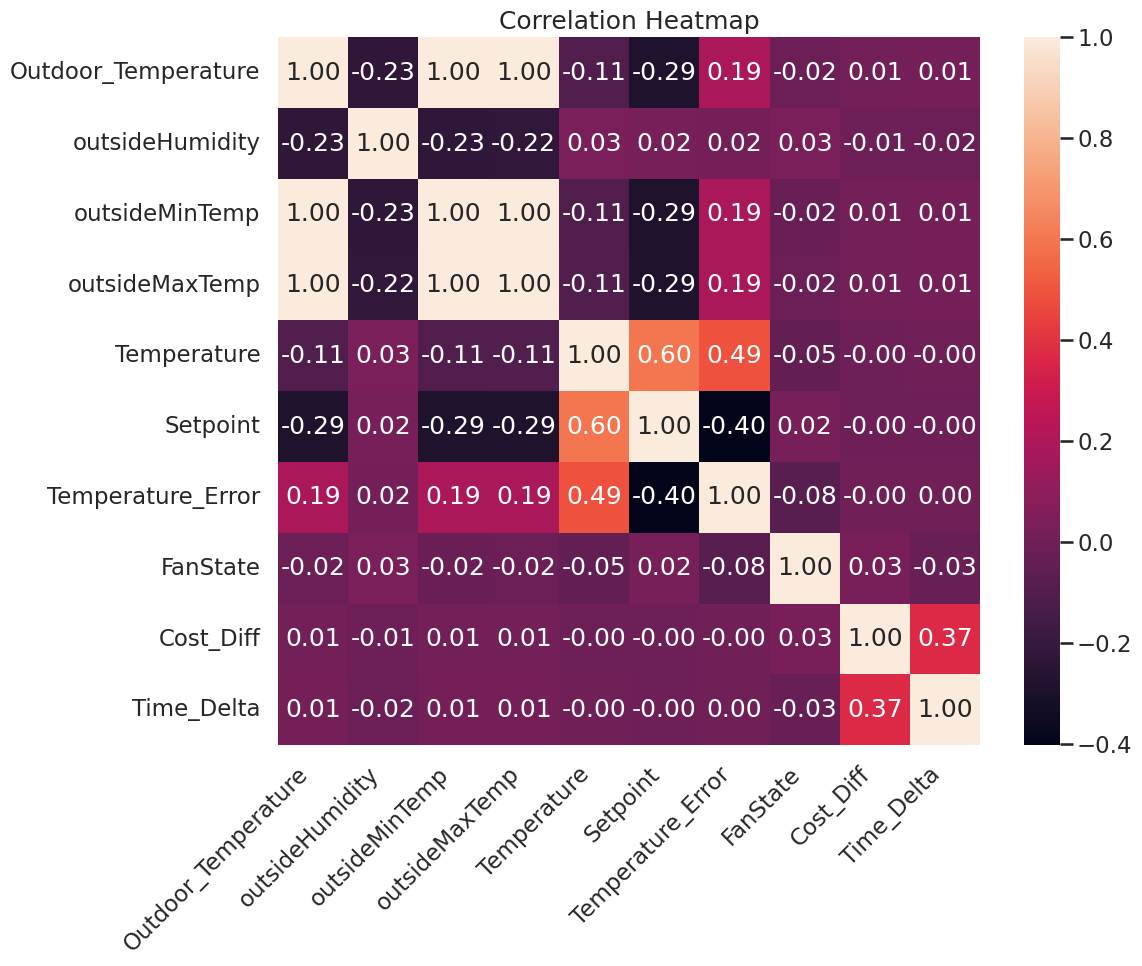

In [13]:
#------------------------------------------------------------------------------
#
# block 5: correlation heatmap
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(12, 10))

# filter expanded target features for correlation logic
#
corr_features = [
    'Outdoor_Temperature', 'outsideHumidity', 'outsideMinTemp', 'outsideMaxTemp',
    'Temperature', 'Setpoint', 'Temperature_Error', 'FanState', 'Cost_Diff', 'Time_Delta'
]
available_features = [c for c in corr_features if c in master_df.columns]

# calculate pearson correlation matrix
#
corr_matrix = master_df[available_features].corr()

# plot heatmap of the correlations restricting annotations to 2 decimal places
#
sns.heatmap(corr_matrix, annot=True, fmt='.2f')

# configure labels and rotate long axis titles to prevent overlap
#
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

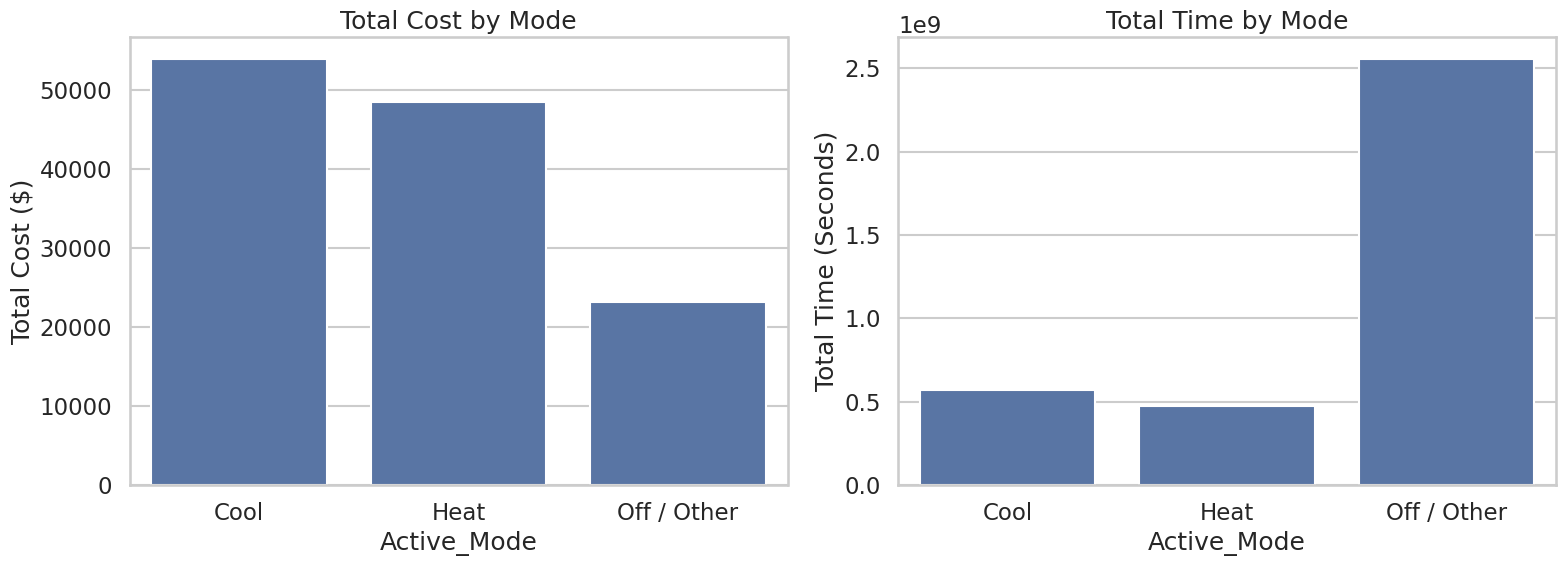

In [6]:
#------------------------------------------------------------------------------
#
# block 6: mode cost and time comparison
#
#------------------------------------------------------------------------------

# establish subplots canvas
#
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot left bar graph containing the total cost comparison
#
sns.barplot(data=mode_totals, x='Active_Mode', y='Cost_Diff', ax=axes[0])
axes[0].set_title('Total Cost by Mode')
axes[0].set_ylabel('Total Cost ($)')

# plot right bar graph containing the total elapsed chronological time
#
sns.barplot(data=mode_totals, x='Active_Mode', y='Time_Delta', ax=axes[1])
axes[1].set_title('Total Time by Mode')
axes[1].set_ylabel('Total Time (Seconds)')

# commit layout
#
plt.tight_layout()
plt.show()

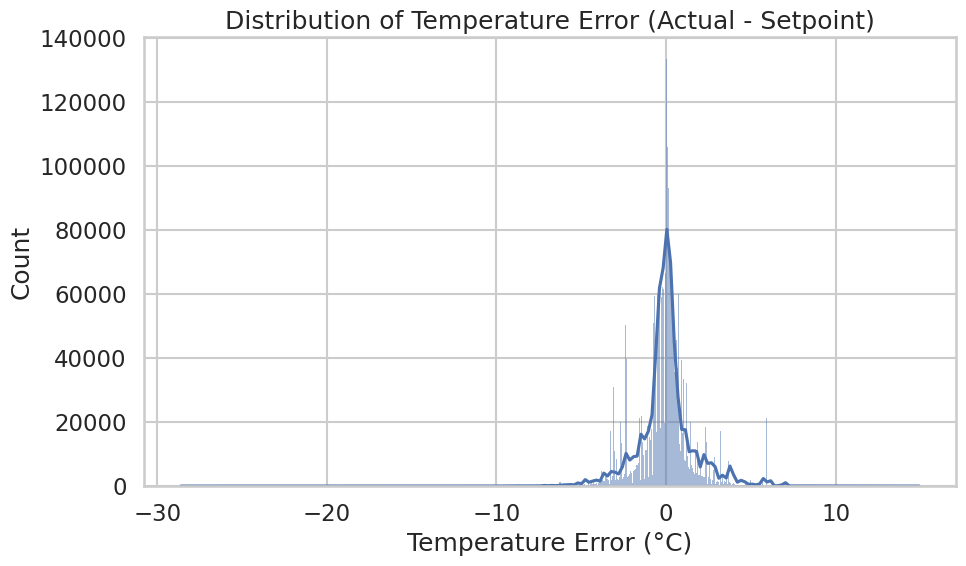

In [7]:
#------------------------------------------------------------------------------
#
# block 7: temperature error distribution
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(10, 6))

# isolate valid errors and plot distribution
#
valid_error = master_df['Temperature_Error'].dropna()
sns.histplot(valid_error, kde=True)

# configure labels
#
plt.title('Distribution of Temperature Error (Actual - Setpoint)')
plt.xlabel('Temperature Error (°C)')
plt.tight_layout()
plt.show()

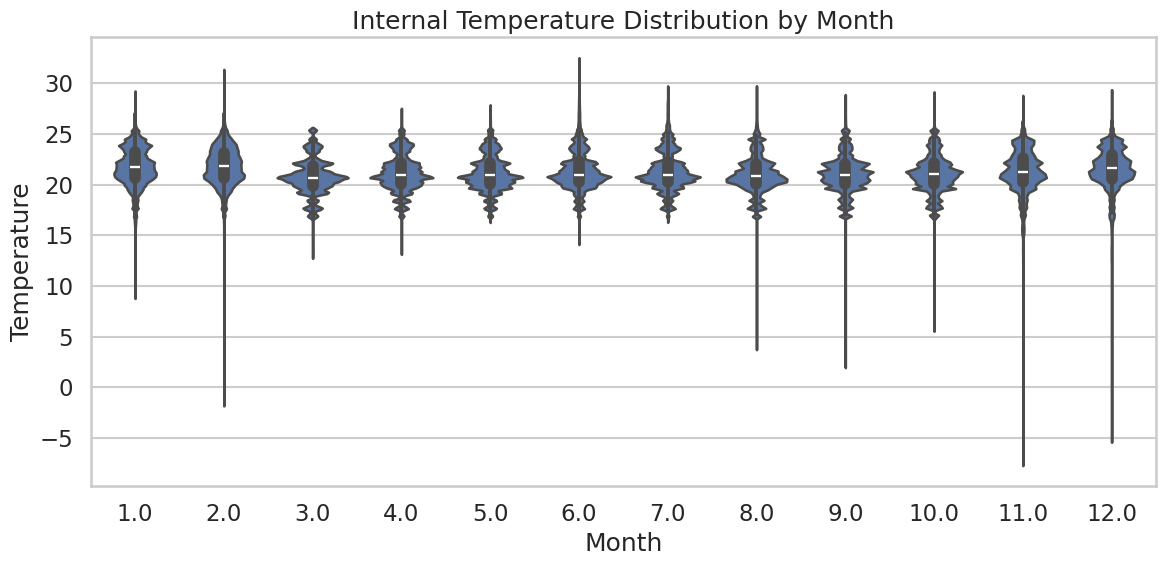

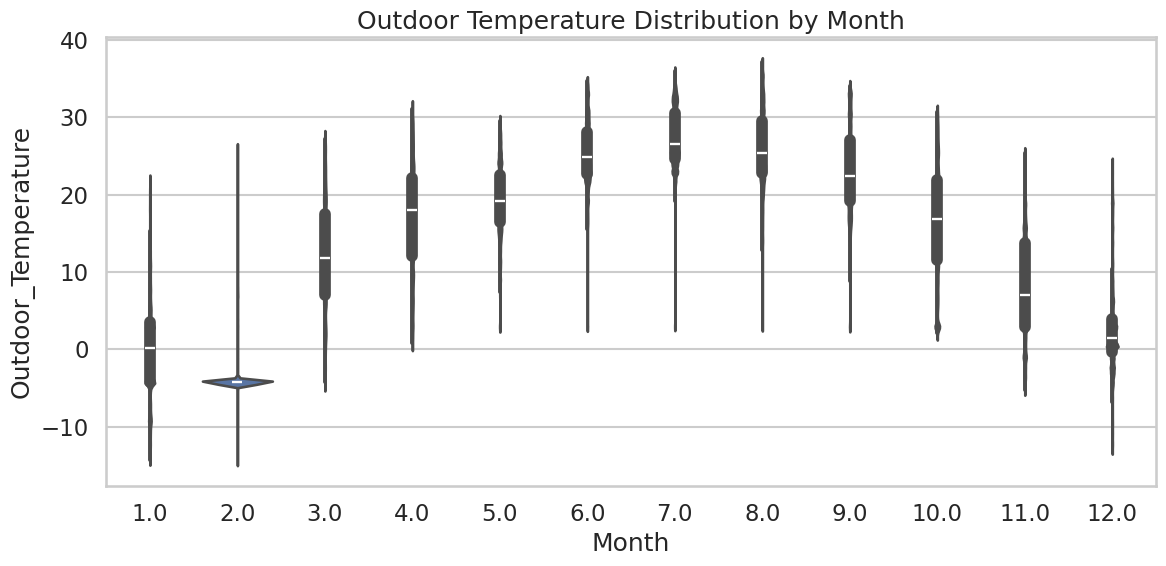

In [8]:
#------------------------------------------------------------------------------
#
# block 8: temperature distributions by month
#
#------------------------------------------------------------------------------

# establish figure canvas for internal temp distribution
#
plt.figure(figsize=(12, 6))

# plot violin distribution across months
#
sns.violinplot(data=master_df, x='Month', y='Temperature')
plt.title('Internal Temperature Distribution by Month')
plt.tight_layout()
plt.show()

# establish figure canvas for outdoor temp distribution
#
plt.figure(figsize=(12, 6))

# plot violin distribution across months
#
sns.violinplot(data=master_df, x='Month', y='Outdoor_Temperature')
plt.title('Outdoor Temperature Distribution by Month')
plt.tight_layout()
plt.show()

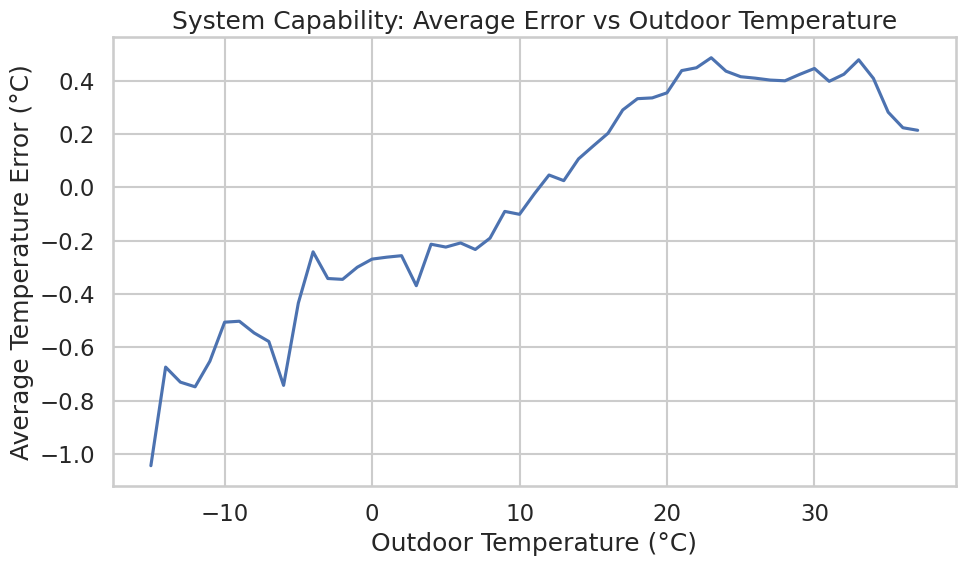

In [9]:
#------------------------------------------------------------------------------
#
# block 9: system capability vs binned outdoor temperature
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(10, 6))

# round outdoor temperature to nearest degree for binned trendline
#
master_df['Outdoor_Bin'] = master_df['Outdoor_Temperature'].round(0)
bin_df = master_df.groupby('Outdoor_Bin', observed=True)['Temperature_Error'].mean().reset_index()

# plot average error per temperature bin
#
sns.lineplot(data=bin_df, x='Outdoor_Bin', y='Temperature_Error')

# configure labels
#
plt.title('System Capability: Average Error vs Outdoor Temperature')
plt.xlabel('Outdoor Temperature (°C)')
plt.ylabel('Average Temperature Error (°C)')
plt.tight_layout()
plt.show()

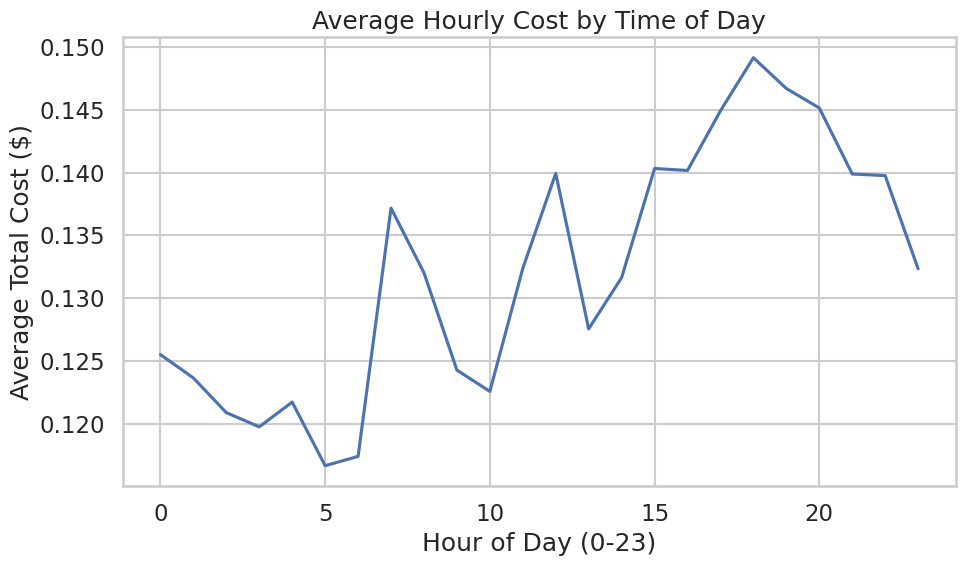

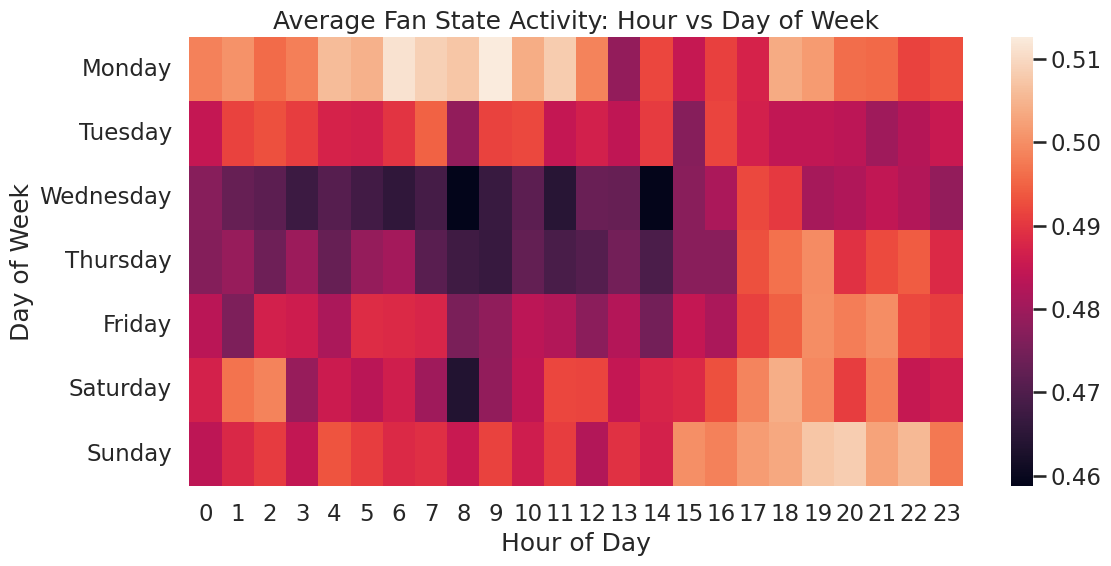

In [15]:
#------------------------------------------------------------------------------
#
# block 10: hourly operations and fan state
#
#------------------------------------------------------------------------------

# establish figure canvas for average hourly costs
#
plt.figure(figsize=(10, 6))

# extract the discrete date to isolate unique historical hours
#
master_df['Date'] = master_df['Timestamp'].dt.date

# sum the incremental costs for every unique hour per house
#
hourly_actuals = master_df.groupby(['House_ID', 'Date', 'Hour'], observed=True)['Cost_Diff'].sum().reset_index()

# calculate the mean average of those 1-hour total blocks
#
hourly_cost = hourly_actuals.groupby('Hour')['Cost_Diff'].mean().reset_index()

# plot cyclic cost trend
#
sns.lineplot(data=hourly_cost, x='Hour', y='Cost_Diff')

# configure labels
#
plt.title('Average Hourly Cost by Time of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Total Cost ($)')
plt.tight_layout()
plt.show()

# establish figure canvas for cyclic fan state heatmap
#
plt.figure(figsize=(12, 6))

# generate pivot table for hour vs day of week
#
fan_pivot = hour_day_df.pivot_table(index='DayOfWeek', columns='Hour', values='FanState', aggfunc='mean', observed=True)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fan_pivot = fan_pivot.reindex(days_order)

# plot heatmap of average fan activity
#
sns.heatmap(fan_pivot)

# configure labels
#
plt.title('Average Fan State Activity: Hour vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

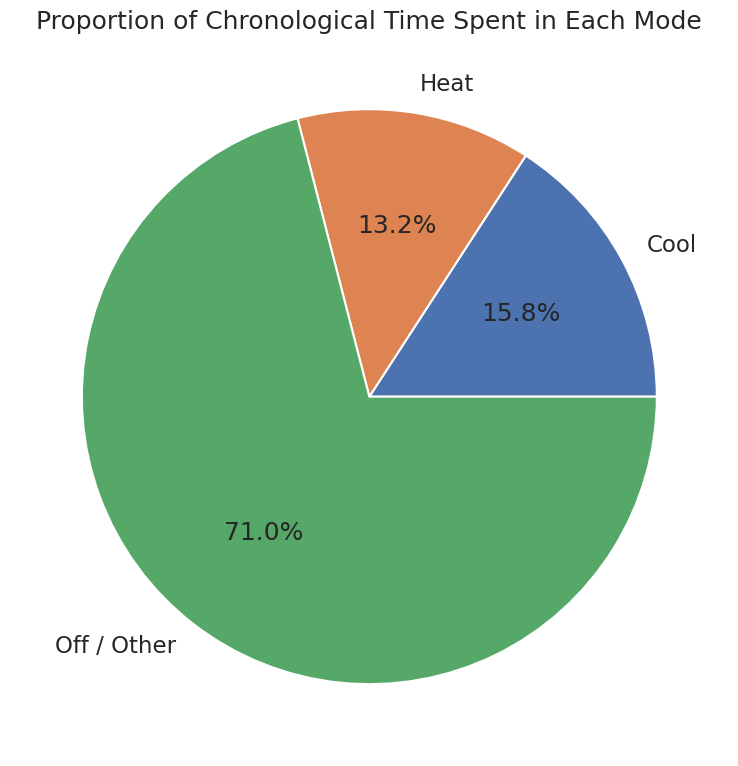

In [11]:
#------------------------------------------------------------------------------
#
# block 11: proportion of time by mode
#
#------------------------------------------------------------------------------

# establish figure canvas
#
plt.figure(figsize=(8, 8))

# base the pie chart on the sum of elapsed chronological time
#
plt.pie(mode_totals['Time_Delta'], labels=mode_totals['Active_Mode'], autopct='%1.1f%%')
plt.title('Proportion of Chronological Time Spent in Each Mode')
plt.tight_layout()
plt.show()

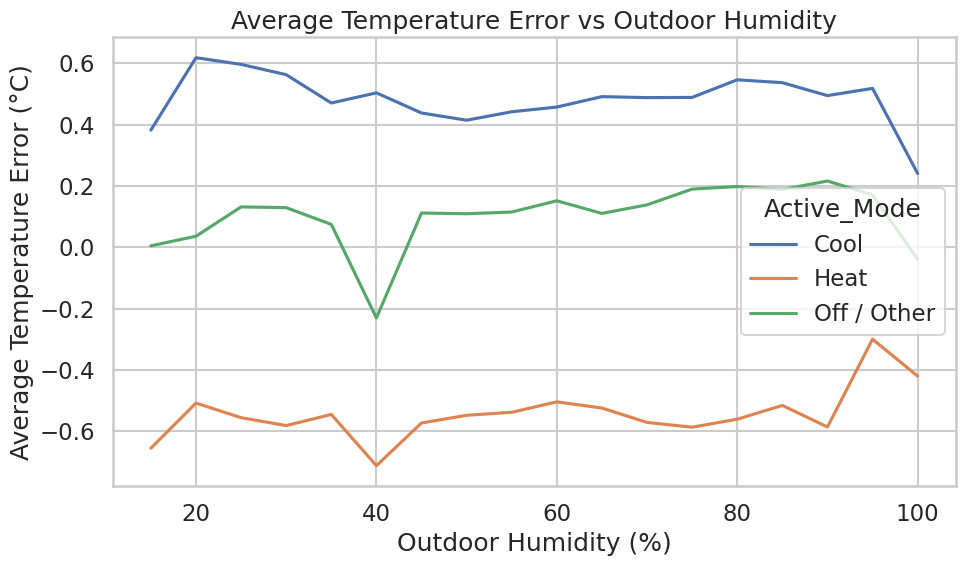

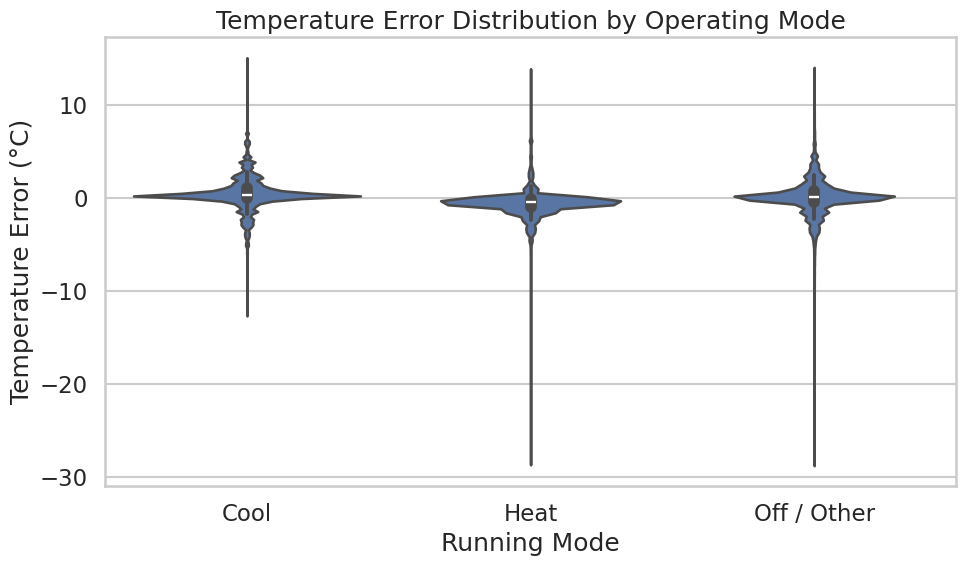

In [16]:
#------------------------------------------------------------------------------
#
# block 12: environmental capabilities and mode errors
#
#------------------------------------------------------------------------------

# establish figure canvas for humidity capability
#
plt.figure(figsize=(10, 6))

# create a localized copy to prevent altering the master dataframe
#
hum_df = master_df.copy()

# round humidity to nearest 5% for binned trendline
#
hum_df['Humidity_Bin'] = (hum_df['outsideHumidity'] // 5) * 5
hum_bin_df = hum_df.groupby(['Humidity_Bin', 'Active_Mode'], observed=True)['Temperature_Error'].mean().reset_index()

# plot binned humidity vs average error
#
sns.lineplot(data=hum_bin_df, x='Humidity_Bin', y='Temperature_Error', hue='Active_Mode')

# configure labels
#
plt.title('Average Temperature Error vs Outdoor Humidity')
plt.xlabel('Outdoor Humidity (%)')
plt.ylabel('Average Temperature Error (°C)')
plt.tight_layout()
plt.show()

# establish figure canvas for error by mode
#
plt.figure(figsize=(10, 6))

# plot error distribution by operating mode across the full dataset
#
sns.violinplot(data=master_df, x='Active_Mode', y='Temperature_Error')

# configure labels
#
plt.title('Temperature Error Distribution by Operating Mode')
plt.xlabel('Running Mode')
plt.ylabel('Temperature Error (°C)')
plt.tight_layout()
plt.show()

#
# end of file